### Main notebook

Run all scripts and show results from here!

In [2]:
import pandas as pd

dataset_csv = pd.read_csv('dataset/rrdataset_new_split.csv')

In [10]:
from modules.data import RRDataset
from torchvision import transforms

CROP = 224
NORM = transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])

# More informative random crops in training
tf_train = transforms.Compose([
    transforms.RandomCrop(CROP),          
    transforms.RandomHorizontalFlip(),   
    transforms.ToTensor(),
    NORM,
])

# Deterministic in evaluation
tf_eval = transforms.Compose([
    transforms.CenterCrop(CROP),
    transforms.ToTensor(),
    NORM,
])

train_set = RRDataset(dataset_csv,'train', apply_transform=tf_train)
val_set = RRDataset(dataset_csv,'val',apply_transform=tf_eval)
train_set = RRDataset(dataset_csv,'test',apply_transform=tf_eval)

In [16]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_set,
    batch_size=32,
    shuffle=True,
    num_workers=4
)

test_loader = DataLoader(
    train_set,
    batch_size=32,
    shuffle=False,
    num_workers=4
)

val_loader = DataLoader(
    val_set,
    batch_size=32,
    shuffle=False,
    num_workers=4
)

In [24]:
data_iter = iter(train_loader)
images, labels, transforms = next(data_iter)

print(f"Image Batches Shape: {images.shape}") # [Batch, Channel, H, W]
print(f"Labels Batch Shape: {labels.shape}")     # [Batch]
print(f"First label value example: {labels[0].item()}")

Image Batches Shape: torch.Size([32, 3, 224, 224])
Labels Batch Shape: torch.Size([32])
First label value example: 1


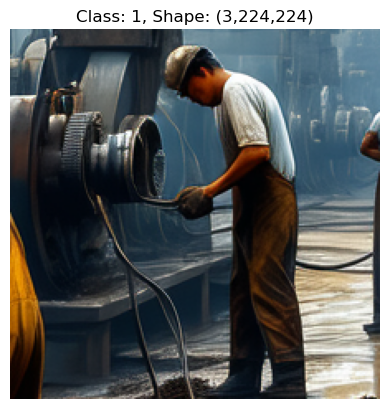

In [ ]:
from modules.utils import show_sample

show_sample(images[0], labels[0].item())